# Explaining "Classical" Models

A linear model seems like the easy case for interpretation. The prediction is a weighted sum, the
weights are right there, and reading off which features matter looks like a matter of sorting a
list.

It is not, and the reasons are worth understanding before we get anywhere near a black box —
because if we cannot correctly interpret a linear model, we have no business claiming to interpret
a neural network.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.metrics import mean_absolute_error
from sklearn.inspection import permutation_importance

DATA_URL = "https://raw.githubusercontent.com/pni-lab/predmod_lecture/master/ex_data/IXI/ixi.csv"

ixi = pd.read_csv(DATA_URL).sample(frac=1, random_state=42).reset_index(drop=True)
TARGET = 'Age'
FEATURES = [c for c in ixi.columns if c.endswith('_volume')]

model = Pipeline([('standardize', StandardScaler()), ('regression', Ridge(alpha=100))])
model.fit(X=ixi[FEATURES], y=ixi[TARGET])

weights = pd.Series(model.named_steps['regression'].coef_, index=FEATURES)
weights.sort_values().head(5).round(3)

rh_superiorfrontal_volume    -2.469
rh_frontalpole_volume        -1.950
lh_superiorfrontal_volume    -1.855
lh_parsopercularis_volume    -1.752
rh_parstriangularis_volume   -1.676
dtype: float64

Because the features were standardized first, these coefficients are comparable with each other:
each is the change in predicted age associated with a one-standard-deviation change in that
region's volume, holding the others constant. That is a real advantage over raw coefficients, whose
size depends on the units of the feature.

So: are these the regions that matter for ageing?

## Problem 1: the weights are not stable

Let's fit the identical model to two random halves of the data and compare.

In [2]:
half_a = ixi.iloc[:319]
half_b = ixi.iloc[319:]

weights_a = pd.Series(model.fit(half_a[FEATURES], half_a[TARGET])
                      .named_steps['regression'].coef_, index=FEATURES)
weights_b = pd.Series(model.fit(half_b[FEATURES], half_b[TARGET])
                      .named_steps['regression'].coef_, index=FEATURES)

print(f'correlation between the two weight vectors: {np.corrcoef(weights_a, weights_b)[0, 1]:.2f}')
print(f'features changing sign between halves     : {int((np.sign(weights_a) != np.sign(weights_b)).sum())} of {len(FEATURES)}')
print()
print('strongest 5 regions, half A:')
print('   ', list(weights_a.abs().sort_values(ascending=False).head(5).index))
print('strongest 5 regions, half B:')
print('   ', list(weights_b.abs().sort_values(ascending=False).head(5).index))

correlation between the two weight vectors: 0.67
features changing sign between halves     : 13 of 68

strongest 5 regions, half A:
    ['lh_insula_volume', 'lh_parsorbitalis_volume', 'rh_superiorfrontal_volume', 'rh_frontalpole_volume', 'rh_isthmuscingulate_volume']
strongest 5 regions, half B:
    ['lh_superiorfrontal_volume', 'rh_parsopercularis_volume', 'lh_parsopercularis_volume', 'lh_insula_volume', 'rh_rostralmiddlefrontal_volume']


Two random halves of the same dataset, the same model, and a substantially different story about
which regions matter — with many coefficients changing sign outright.

The cause is collinearity, which we have known about since
[chapter 1](../1_python_basics/data_frames.ipynb): regional volumes are strongly correlated with
one another. When two features carry nearly the same information, the fitting procedure has no
principled way to divide the credit between them, and small differences in the sample push the
weight from one to the other. Ridge regression spreads weight across a correlated group, which
stabilizes *predictions* but does not make the individual coefficients meaningful. LASSO is worse
for this purpose: it picks one member of each correlated group and zeroes the rest, so the
"selected features" can change completely with a handful of participants.

```{margin} A rule worth adopting
Before interpreting any coefficient, refit the model on random subsamples and look at how much it
moves. If you would not bet on the sign, do not write a sentence about the direction of the effect.
```

## Problem 2: a weight is not an importance

The deeper issue is conceptual, and it is the one most often missed in the neuroimaging literature.

A predictive model is a **backward model**: it maps measurements to the thing you want to know.
Its weights answer the question *how should I combine these features to reconstruct the target?*
They do not answer *which features carry information about the target?* — and the two can differ
dramatically.

The classic example: a feature may receive a large weight not because it relates to the target, but
because it captures noise present in *other* features, which the model needs to subtract. Such a
**suppressor variable** can have a large coefficient while being completely uncorrelated with the
target. Conversely, a feature strongly related to the target can get a weight of zero because a
correlated neighbour already carries the information.

{cite:t}`haufe2014interpretation` showed how to convert a backward model into the corresponding
**forward model** — the pattern that describes how the target is actually expressed in the
features. For a linear model, the transformation is remarkably simple:

$$
\boldsymbol{A} = \boldsymbol{\Sigma}_X \, \boldsymbol{w} \, \sigma^{-2}_{\hat{y}}
$$

where $\boldsymbol{\Sigma}_X$ is the covariance matrix of the (standardized) features,
$\boldsymbol{w}$ the model weights, and $\sigma^{2}_{\hat{y}}$ the variance of the model output —
a scalar, so it rescales the pattern without changing its shape, and we drop it below. The resulting pattern $\boldsymbol{A}$ is interpretable as
"how each feature reflects the signal the model extracted" — and it is what should be plotted on a
brain, not the weights.

In [3]:
model.fit(X=ixi[FEATURES], y=ixi[TARGET])
weights = pd.Series(model.named_steps['regression'].coef_, index=FEATURES)

standardized = StandardScaler().fit_transform(ixi[FEATURES])
haufe_pattern = pd.Series(np.cov(standardized, rowvar=False) @ weights.values, index=FEATURES)

univariate = ixi[FEATURES].corrwith(ixi[TARGET])      # the plain feature-target association

comparison = pd.DataFrame({'model weight': weights,
                           'Haufe pattern': haufe_pattern,
                           'correlation with age': univariate})

print('agreement with the plain feature-target correlation:')
print(f'   raw model weights: r = {comparison["model weight"].corr(univariate):.2f}')
print(f'   Haufe pattern    : r = {comparison["Haufe pattern"].corr(univariate):.2f}')
print()
print(f'model weights that have the opposite sign to the feature-target correlation: '
      f'{int((np.sign(weights) != np.sign(univariate)).sum())} of {len(FEATURES)}')

agreement with the plain feature-target correlation:
   raw model weights: r = 0.60
   Haufe pattern    : r = 1.00

model weights that have the opposite sign to the feature-target correlation: 30 of 68


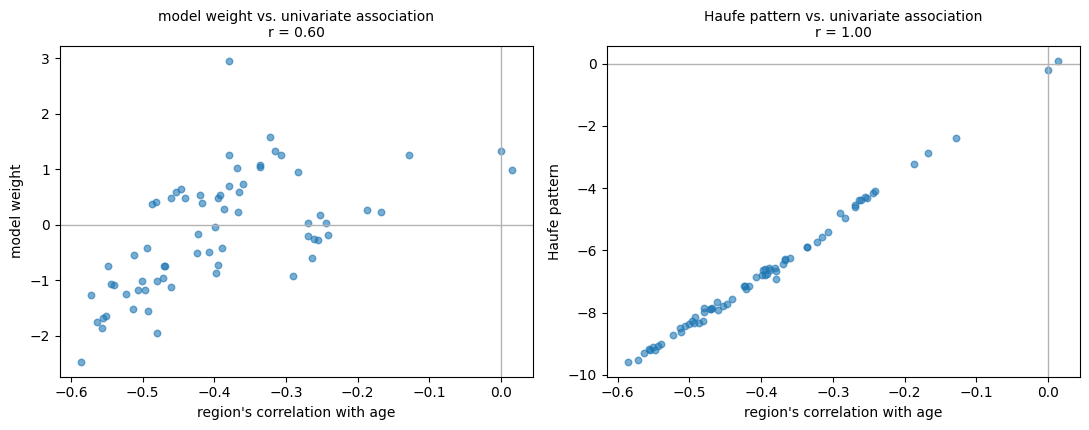

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, column in zip(axes, ['model weight', 'Haufe pattern']):
    ax.scatter(comparison['correlation with age'], comparison[column], alpha=0.6, s=22)
    ax.axhline(0, color='0.7', lw=1)
    ax.axvline(0, color='0.7', lw=1)
    ax.set_xlabel("region's correlation with age")
    ax.set_ylabel(column)
    ax.set_title(f'{column} vs. univariate association\n'
                 f'r = {comparison[column].corr(univariate):.2f}', fontsize=10)
plt.tight_layout()
plt.show()

The left panel is the map that gets published. The right panel is the one that means something.

Nearly half of the model's weights — 30 of 68 — point in the *opposite* direction to the region's
own association with age: regions whose volume declines with age receive a positive weight, and
vice versa. Read naively, those would be reported as "regions where more volume means an older brain",
which is the reverse of the truth. They are suppressors: the model is using them to cancel
variance it does not want, which is a legitimate thing for a predictor to do and a terrible thing
to put in a figure.

The Haufe-transformed pattern lines up with the univariate associations almost exactly (r = 1.00).
Part of that is exact by construction: the forward pattern *is*, up to a scale factor, the
covariance between each feature and the model's own output $\hat{y}$. That it also agrees this
closely with each feature's covariance with the *true* target is an empirical fact about this
heavily regularized model, not a mathematical identity — a model that predicted badly would show
the two coming apart.

That symmetry invites an obvious objection — if the interpretable pattern is essentially the
univariate associations, why fit a multivariate model at all? Because the two are for different
jobs. The multivariate model *predicts*: it combines 68 weak, redundant signals into one estimate
far better than any single region could. The forward pattern *describes*: it says where in the
brain the extracted signal lives. Using the backward weights for the descriptive job is the error;
the multivariate model has not become unnecessary, it has simply never been the right object to
read anatomy off.

```{warning}
This applies to every backward model — every classifier and regressor trained to predict from
measurements. If you have ever plotted the weight map of an SVM or a logistic regression on a brain
and interpreted the anatomy, this is the correction you needed.
```

## What the coefficients still cannot tell you

Even a properly transformed pattern is a statement about *association*, not about mechanism. It
tells you how the target is expressed in your measurements, in this sample, with this
preprocessing. It does not tell you that the region does anything, that intervening on it would
change the target, or that it would appear again in a different cohort.

And it remains entirely compatible with the model being confounded. Our brain-age model is
substantially driven by total cortical volume ([chapter 6](../6_validity/validity.ipynb)); the
Haufe pattern shows *where* that plays out anatomically, but says nothing about whether the
underlying signal is ageing or head size.

## Permutation importance: asking the model what it uses

A different approach sidesteps coefficients entirely: shuffle one feature, see how much worse the
predictions get. The bigger the damage, the more the model was relying on it. This works for any
model, which is why we meet it again on [the next page](black_box.ipynb).

In [5]:
model.fit(X=half_a[FEATURES], y=half_a[TARGET])
importance = permutation_importance(model, X=half_b[FEATURES], y=half_b[TARGET],
                                    scoring='neg_mean_absolute_error',
                                    n_repeats=20, random_state=42, n_jobs=-1)

ranked = pd.Series(importance.importances_mean, index=FEATURES).sort_values(ascending=False)

print('most important regions by permutation importance (years of MAE lost when shuffled):')
print(ranked.head(5).round(3).to_string())
print()
print(f'largest single importance: {ranked.iloc[0]:.3f} years')
print(f'sum of all importances   : {ranked.sum():.3f} years')

most important regions by permutation importance (years of MAE lost when shuffled):
rh_superiorfrontal_volume    0.576
lh_parsorbitalis_volume      0.546
rh_frontalpole_volume        0.466
lh_parsopercularis_volume    0.336
lh_insula_volume             0.285

largest single importance: 0.576 years
sum of all importances   : 6.026 years


Notice how small these numbers are. Shuffling the single most important region costs a fraction of
a year of accuracy — because 67 correlated regions remain, and they carry much the same
information. **Permutation importance measures how much a feature is needed *given all the
others*, not how much information it carries.** With collinear features, everything looks
unimportant, and the sum of the individual importances bears no relation to the model's total
performance.

This is not a flaw to be fixed by a better algorithm; it is the correct answer to the question
being asked. If you want to know whether a region carries information about age, fit a model with
only that region and cross-validate it. If you want to know whether it adds information beyond the
others, permutation importance is your tool. These are different questions with different answers,
and conflating them produces most of the confusion in the literature on feature importance.

Note too that the individual importances do not add up to anything in particular — they are not a
decomposition of the model's performance, and with correlated features they can sum to more or
less than the model's total advantage over the baseline.

:::{admonition} Exercise 7.1
:class: tip, dropdown
Take the region with the highest permutation importance and the region with the *lowest*, and
cross-validate a single-feature model with each. Does the ranking survive?

:::{admonition} Solution
:class: note, dropdown
Often not, and sometimes it reverses. A region can be individually informative and redundant given
the rest (low permutation importance, good single-feature model), or individually uninformative
but useful as a suppressor (the opposite). Both "importances" are real; they answer different
questions.
:::
:::

:::{admonition} Exercise 7.2
:class: tip, dropdown
Repeat the two-halves stability analysis for the Haufe-transformed pattern instead of the raw
weights. Is it more stable? Why would you expect it to be?

:::{admonition} Solution
:class: note, dropdown
Considerably more stable. The instability of the weights comes from the arbitrary division of
credit among correlated features; multiplying by the covariance matrix undoes precisely that
division, mapping the weights back into the space of observable associations, which are estimated
far more reliably.
:::
:::

Linear models, then, are interpretable only with care, and the naive reading of their coefficients
is usually wrong. That is worth holding onto when we turn, on
[the next page](black_box.ipynb), to models with no coefficients at all.